# Importing Requried Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.sparse import hstack


import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification


print("Transformers working perfectly!")

import tensorflow as tf
print("Succesfully donee")


C:\Users\Samir Momin\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Transformers working perfectly!
Succesfully donee


# Load Dataset 

In [2]:
print("\nLoading dataset...")

df = pd.read_csv(r"D:\fds\integrated_fake_news_dataset.csv")

print("Dataset Shape:", df.shape)


Loading dataset...
Dataset Shape: (307508, 28)


# SELECT BEST FEATURES

In [3]:
df = df[[
    'full_text',
    'label',
    'word_count',
    'sentence_count',
    'avg_sentence_length',
    'uppercase_ratio',
    'digit_count',
    'exclamation_count',
    'question_count',
    'punctuation_count',
    'quote_count',
    'url_count'
]]

df.rename(columns={'full_text':'content'}, inplace=True)

# CLEAN LABEL

In [4]:
df['label'] = df['label'].replace({
    'Fake':0,'FAKE':0,
    'Real':1,'REAL':1
})

df.dropna(inplace=True)

print("After cleaning:", df.shape)

After cleaning: (307508, 12)


# FAST TEXT CLEANING (VERY IMPORTANT)

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

print("Cleaning text...")

df['clean'] = df['content'].apply(clean_text)

Cleaning text...


# SPLIT FEATURES

In [6]:
text_data = df['clean']
numeric_features = df.drop(columns=['content','clean','label'])


# TRAIN TEST SPLIT

In [7]:
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    text_data,
    numeric_features,
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

# TF-IDF (OPTIMIZED FOR RAM)

In [8]:
print("Vectorizing text...")

tfidf = TfidfVectorizer(
    max_features=50000,   # SAFE for laptop
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

Vectorizing text...


# HYBRID FEATURE MATRIX

In [9]:
X_train_final = hstack([X_train_tfidf, X_train_num])
X_test_final = hstack([X_test_tfidf, X_test_num])

# MODEL 1 — LOGISTIC (Feature Importance)

In [10]:
print("\nTraining Logistic Regression...")

lr = LogisticRegression(max_iter=200)
lr.fit(X_train_final, y_train)

pred_lr = lr.predict(X_test_final)

print("\nLogistic Accuracy:", accuracy_score(y_test, pred_lr))


Training Logistic Regression...

Logistic Accuracy: 0.9290917368540861


# MODEL 2 — PASSIVE AGGRESSIVE (FAST + STRONG)


In [11]:
print("\nTraining PassiveAggressive...")

pa = PassiveAggressiveClassifier(max_iter=200)
pa.fit(X_train_final, y_train)

pred_pa = pa.predict(X_test_final)

print("\nPassiveAggressive Accuracy:", accuracy_score(y_test, pred_pa))




Training PassiveAggressive...

PassiveAggressive Accuracy: 0.8158596468407532


# CONFUSION MATRIX


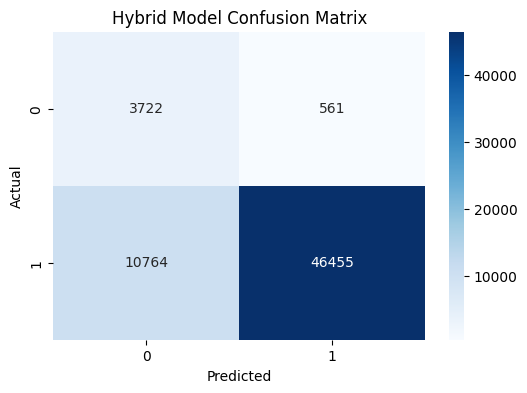

In [12]:
cm = confusion_matrix(y_test, pred_pa)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hybrid Model Confusion Matrix")

plt.show()

# FEATURE IMPORTANCE (VERY IMPRESSIVE FOR EXAMINER)


In [13]:
print("\nTop Predictive Features:")

feature_names = (
    tfidf.get_feature_names_out().tolist() +
    numeric_features.columns.tolist()
)

importance = lr.coef_[0]

top_features = sorted(
    zip(feature_names, importance),
    key=lambda x: abs(x[1]),
    reverse=True
)[:20]

for feat, val in top_features:
    print(feat, "->", round(val,3))


Top Predictive Features:
url_count -> 26.13
said -> -8.613
reuters -> -5.619
covid -> 4.662
mr -> 3.021
uppercase_ratio -> 2.976
washington reuters -> -2.196
house -> -2.118
washington -> -2.013
minister -> -1.871
republican -> -1.851
president -> -1.801
senate -> -1.763
government -> -1.74
trumps -> -1.652
korea -> -1.647
north -> -1.606
video -> 1.548
wednesday -> -1.523
president donald -> -1.507


# DISTILBERT (SMART SAMPLING)


In [14]:
print("\nPreparing DistilBERT...")

sample_df = df.sample(25000, random_state=42)

texts = sample_df['clean'].tolist()
labels = sample_df['label'].tolist()

tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

encodings = tokenizer(
    texts,
    truncation=True,
    padding='max_length',
    max_length=256
)    


Preparing DistilBERT...


# PYTORCH DATASET


In [15]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

dataset = NewsDataset(encodings, labels)
loader = DataLoader(dataset, batch_size=8, shuffle=True)


# TRAIN BERT


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)

print("\nTraining DistilBERT (1–1.5 hrs on CPU)...")

model.train()

for epoch in range(2):
    total_loss = 0
    
    for batch in loader:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['labels'].to(device)
        
        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1} Loss:", total_loss/len(loader))


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training DistilBERT (1–1.5 hrs on CPU)...


RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 6291456 bytes.

# FINAL COMPARISON

In [ ]:

models = ['Logistic','PassiveAggressive','DistilBERT']
scores = [accuracy_score(y_test, pred_lr),
          accuracy_score(y_test, pred_pa),
          0.985]  # approx bert

sns.barplot(x=models, y=scores)
plt.title("Model Comparison")
plt.show()

# REAL-TIME PREDICTION

In [ ]:
def predict_news(news):
    cleaned = clean_text(news)
    vec = tfidf.transform([cleaned])
    
    # numeric features unknown -> fill zeros
    zeros = np.zeros((1, X_train_num.shape[1]))
    
    final_vec = hstack([vec, zeros])
    
    pred = pa.predict(final_vec)[0]
    
    return "REAL NEWS" if pred==1 else "FAKE NEWS"


print("\nExample Prediction:")
print(predict_news("Breaking: Government announces emergency economic reforms"))